In [5]:
!pip install wurlitzer
from wurlitzer import sys_pipes_forever

sys_pipes_forever()

In [6]:
#using uproot to write generated event into TTree

!pip install uproot
import uproot

import numpy as np
import pandas as pd



In [7]:
#create a class for jets, to overload the __add__ operation

class MJet:
  """
  class for jets, containing 4-momenta and other useful information for jet clustering;
  argument is simply 4-momenta (E,px,py,pz)
  makes use of NumPy for vectorized operations, and other math operations
  """

  def __init__(self, E, px, py, pz):
    self.E = E
    self.px = px
    self.py = py
    self.pz = pz



    self.pT = float(np.sqrt(px**2 + py**2))
    self.p = float(np.sqrt(px**2 + py**2 + pz**2))

    self.phi = float(np.arctan2(self.py, self.px))

    # Calculate mass, add tolerance (1e-6)for floating point issues
    m_squared = self.E**2 - self.p**2
    if m_squared < 0 and np.isclose(m_squared, 0, atol=1e-6): # Treat small negative as zero
        self.m = 0.0
    else:
        self.m = float(np.sqrt(m_squared))

                                                                                                                                                    # Calculate eta, handling edge cases for rapidity
                                                                                                                                                    # maybe also use np.isclose()
    if self.E + self.pz == 0:
        self.eta = -np.inf
    elif self.E - self.pz == 0:
        self.eta = np.inf
    else:
        self.eta = (1/2)*float( np.log( (self.E + self.pz) / (self.E - self.pz) ) )


  def __str__(self):

    output = {
        "E": self.E,
        "px": self.px,
        "py": self.py,
        "pz": self.pz,
        "pT": self.pT,
        "p": self.p,
        "phi": self.phi,
        "eta": self.eta,
        "m": self.m
    }
    return str(output)


  def __add__(self, other):
    return MJet(self.E + other.E, self.px + other.px, self.py + other.py, self.pz + other.pz)

  def __eq__(self, other):
    return (self.E == other.E) and (self.px == other.px) and (self.py == other.py) and (self.pz == other.pz)





In [8]:
#read event data

file4 = uproot.open("PythiaEventsBatchTest.root")

tree = file4['pdEventTree']

#read branches into Awkward array, then numpy arrays

E_array = tree['E'].array().to_numpy()
px_array = tree['px'].array().to_numpy()
py_array = tree['py'].array().to_numpy()
pz_array = tree['pz'].array().to_numpy()
eta_array = tree['eta'].array().to_numpy()
phi_array = tree['phi'].array().to_numpy()



In [9]:
# making the jets

jet_set = [MJet(E_array[i],px_array[i],py_array[i],pz_array[i]) for i in range(len(E_array))]


In [10]:
def d_ij(j1, j2, R_0, epsilon=1e-6):
  """
  Cambridge-Aachen distance metric between two jets. Note: the original d_ij used min_kT, which is characteristic
  of the generalized k_t algorithm, but for Cambridge-Aachen it should use min(1/pT1^2, 1/pT2^2).

  Parameters:
      j1 (MJet): The first jet.
      j2 (MJet): The second jet.
      R_0 (float): The jet radius parameter.
      epsilon (float): A small positive value to avoid division by zero from floating point inaccuracies

  Returns:
      float: The distance between the jets.
  """

  delta_R_sq = (j1.eta - j2.eta)**2 + (j1.phi - j2.phi)**2

  output = (delta_R_sq / (R_0**2))

  return output

def d_iB(j, epsilon=1e-6):
  """
  Cambridge-Aachen beam distance: k_T^{2*n} = 1, with n = 0 for Cambridge-Aachen clustering

  Parameters:
      j (MJet): The jet.

  Returns:
      float: The beam distance.
  """
  return 1.0

In [11]:
# defining the anti-kT clustering function to do the clustering


# track all active jets yet to be dropped/clustered, as well as final state jets
# initialize minimum distance as infinity, active jet set as initial jet set, final state jet set as empty
# calculate beam distances (d_iB) and pairwise distances (d_ij)
#   while tracking minimum distance, and type (beam/pairwise), which determines whether we cluster or add to final set,
    # as well as indices of prospective jets to be merged/promoted to final jet
# Then, update active jet and final jet lists, before continuing the loop

def ca_clustering(j_initial, R_0, thresholding=False, pT_threshold=0.0, eta_threshold=0.0):
  """
  Function for clustering an input set of jets, using anti-kT clustering algorithm,
  to return a set of final-state jets.

  Parameters:

    j_initial: List of initial jets,
    R_0: the jet radius parameter,

    thresholding: Boolean, configurable by user in case they wish to apply jet pT and eta thresholds; off by default
    pT_threshold: minimum jet pT,
    eta_threshold: minimum jet eta,

  Returns:
    List of final-state jets

  """

  active = list(j_initial)  #list of jets being clustered, make a copy to avoid modifying original
  final_jets = []  #to store final state jets

  # Main loop
  while active:

    d_min = float('inf')
    indices_min = None  #indices of jets to either be clustered or promoted to final state
    type_min = None #determine whether d_iB, d_ij is minimum, and thus whether to cluster/promote jet

    #Calculate d_iB, and see if anything can be promoted to final jet

    for i, j_i in enumerate(active):

      diB = d_iB(j_i)

      if diB < d_min:
        d_min = diB
        indices_min = (i,)
        type_min = 'beam'

    #Calculate d_ij and see if anything can be clustered

    for i in range(len(active)):

      for j in range(i+1, len(active)):

        dij = d_ij(active[i], active[j],R_0)

        if dij < d_min:
          d_min = dij
          indices_min = (i, j)
          type_min = 'pairwise'

    #Now, either cluster/promote

    if type_min == 'beam':
      j_candidate = active.pop(indices_min[0])
      final_jets.append(j_candidate)

    elif type_min == 'pairwise':
      idx1, idx2 = sorted(indices_min, reverse=True)
      j_i = active.pop(idx1)
      j_j = active.pop(idx2)

      active.append(j_i + j_j)

    else:
      raise ValueError("Invalid type_min value: No valid clustering or beam distance found.")

  # Apply thresholding after clustering is complete
  if thresholding:
    filtered_final_jets = []
    for jet in final_jets:
      # Assuming eta_threshold is a maximum absolute eta value
      if jet.pT >= pT_threshold and abs(jet.eta) <= eta_threshold:
        filtered_final_jets.append(jet)
    return filtered_final_jets
  else:
    return final_jets

In [12]:
clustered_jets = ca_clustering(jet_set,0.4)

In [15]:
#writing output final jets to data file:

file_out = uproot.recreate("FinalJets_CA.root")

output_dict = {
    "E": [jet.E for jet in clustered_jets],
    "px": [jet.px for jet in clustered_jets],
    "py": [jet.py for jet in clustered_jets],
    "pz": [jet.pz for jet in clustered_jets]
}

output_df = pd.DataFrame(output_dict)

file_out.mktree("finalJets", output_df)

file_out["finalJets"]



<WritableTree '/finalJets' at 0x7a6d78a14e90>

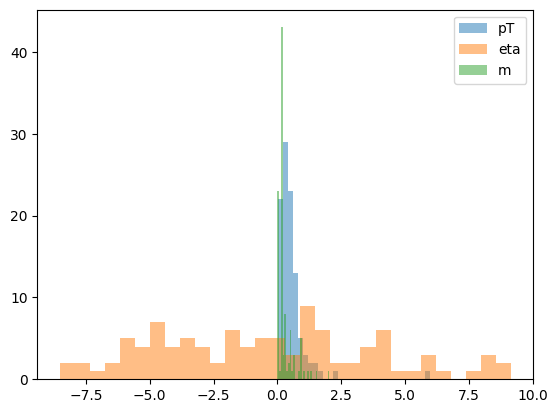

In [16]:
#Plotting distributions from final jets


import matplotlib.pyplot as plt


pT_values = [jet.pT for jet in clustered_jets]
eta_values = [jet.eta for jet in clustered_jets]
m_values = [jet.m for jet in clustered_jets]

plt.hist(pT_values, bins=30, alpha=0.5, label='pT')
plt.hist(eta_values, bins=30, alpha=0.5, label='eta')
plt.hist(m_values, bins=30, alpha=0.5, label='m')
plt.legend()
plt.show()